<a href="https://colab.research.google.com/github/swamini-10/DESIGN-ANALYSIS-AND-ALGORITHMS-TASKS/blob/main/A1_B4_60_Swamini_Gawande_DAA_TA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name-Swamini Gawande

Class-A1

Roll no.-60

Batch-B4

DAA TEACHER ASSESSMENT

Q1. Real-World Application: Sensor Placement in IoT Networks

Question:
Model a smart city IoT sensor network as a graph where edges represent communication
links between sensors.

1. Formulate the sensor placement optimization as a Vertex Cover Problem.

2. Implement and compare the following algorithms for selecting minimum monitoring
nodes:

o Greedy 2-approximation

o LP-relaxation

o Randomized heuristic

3. Use NetworkX to generate a synthetic IoT graph (500–1000 nodes, varying density).

4. Measure and compare:

o Number of selected sensors

o Execution time

o Coverage completeness

5. Discuss trade-offs between computational time and solution accuracy.

6. Suggest improvements (e.g., hybrid algorithms, local search, metaheuristics).
Expected Outcome:

Bridges theoretical graph algorithms to real-world optimization scenarios.

In [ ]:
!pip install networkx matplotlib numpy cvxpy


Graph n=500, p=0.002 -> Done
Graph n=500, p=0.005 -> Done
Graph n=500, p=0.010 -> Done


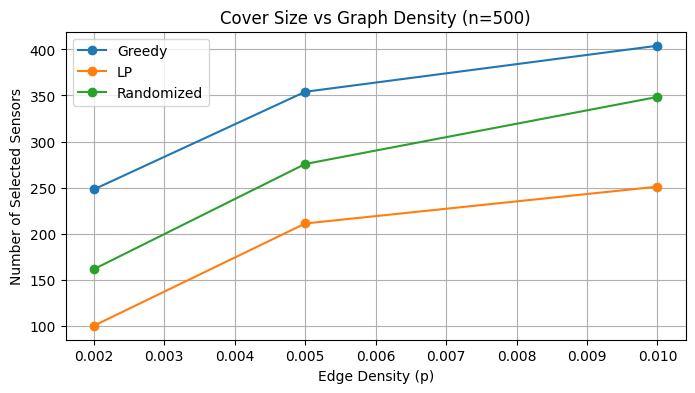

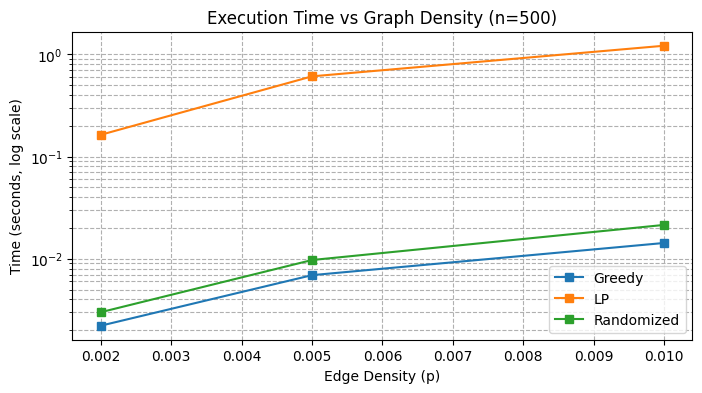

In [ ]:
import time
import random
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp   # For LP-relaxation

# Algorithms

def greedy_vertex_cover(G):
    """Greedy 2-approximation algorithm"""
    start = time.time()
    cover = set()
    edges = set(G.edges())
    while edges:
        u, v = edges.pop()
        cover.add(u)
        cover.add(v)
        edges = {e for e in edges if u not in e and v not in e}
    return cover, time.time() - start


def lp_relaxation_vertex_cover(G):
    """Linear Programming relaxation for Vertex Cover"""
    start = time.time()
    n = G.number_of_nodes()
    nodes = list(G.nodes())
    index = {nodes[i]: i for i in range(n)}

    x = cp.Variable(n)
    constraints = [x[index[u]] + x[index[v]] >= 1 for u, v in G.edges()]
    constraints += [x >= 0, x <= 1]
    objective = cp.Minimize(cp.sum(x))
    prob = cp.Problem(objective, constraints)
    prob.solve(solver="SCS", verbose=False)

    cover = {nodes[i] for i in range(n) if x.value[i] >= 0.5}
    return cover, time.time() - start


def randomized_vertex_cover(G):
    """Randomized heuristic algorithm"""
    start = time.time()
    edges = set(G.edges())
    cover = set()
    while edges:
        u, v = random.choice(list(edges))
        chosen = random.choice([u, v])
        cover.add(chosen)
        edges = {e for e in edges if chosen not in e}
    return cover, time.time() - start


def coverage_fraction(G, cover):
    """Fraction of edges covered"""
    if G.number_of_edges() == 0:
        return 1.0
    covered = sum(1 for (u, v) in G.edges() if u in cover or v in cover)
    return covered / G.number_of_edges()

# Experiments

def run_experiments(node_sizes=[500], densities=[0.002, 0.005, 0.01], trials=5):
    results = []
    for n in node_sizes:
        for p in densities:
            G = nx.erdos_renyi_graph(n=n, p=p, seed=42)

            # Greedy
            g_cover, g_time = greedy_vertex_cover(G)

            # LP-relaxation
            lp_cover, lp_time = lp_relaxation_vertex_cover(G)

            # Randomized (average of trials)
            r_sizes, r_times = [], []
            for _ in range(trials):
                r_cover, r_time = randomized_vertex_cover(G)
                r_sizes.append(len(r_cover))
                r_times.append(r_time)

            results.append({
                "n": n,
                "p": p,
                "Greedy": (len(g_cover), g_time, coverage_fraction(G, g_cover)),
                "LP": (len(lp_cover), lp_time, coverage_fraction(G, lp_cover)),
                "Randomized": (np.mean(r_sizes), np.mean(r_times), 1.0)
            })

            print(f"Graph n={n}, p={p:.3f} -> Done")

    return results

# Visualization with log scale for time

def plot_results(results):
    densities = sorted(set(r["p"] for r in results))
    algos = ["Greedy", "LP", "Randomized"]

    for n in sorted(set(r["n"] for r in results)):
        # Cover Size
        plt.figure(figsize=(8,4))
        for algo in algos:
            sizes = [r[algo][0] for r in results if r["n"] == n]
            plt.plot(densities, sizes, marker='o', label=algo)
        plt.title(f"Cover Size vs Graph Density (n={n})")
        plt.xlabel("Edge Density (p)")
        plt.ylabel("Number of Selected Sensors")
        plt.grid(True)
        plt.legend()
        plt.show()

        # Execution Time (log scale)
        plt.figure(figsize=(8,4))
        for algo in algos:
            times = [r[algo][1] for r in results if r["n"] == n]
            plt.plot(densities, times, marker='s', label=algo)
        plt.yscale("log")  # Makes small times visible
        plt.title(f"Execution Time vs Graph Density (n={n})")
        plt.xlabel("Edge Density (p)")
        plt.ylabel("Time (seconds, log scale)")
        plt.grid(True, which="both", ls="--")
        plt.legend()
        plt.show()

# Main
if __name__ == "__main__":
    results = run_experiments()
    plot_results(results)

2. Randomized and Probabilistic Vertex Cover Algorithms

Question:
In massive networks, deterministic algorithms are often infeasible. Randomized algorithms
can yield efficient approximate vertex covers.
1. Design a randomized algorithm for Vertex Cover based on the following idea:

o Randomly select an uncovered edge (u,v)(u,v)(u,v),

o Randomly include either uuu or vvv in the vertex cover,

o Repeat until all edges are covered.

2. Implement the algorithm in Python or C++ and run it on multiple random graphs
(generated using NetworkX).

3. Compute and plot:

o Average vertex cover size

o Variance of results over 100 trials

o Execution time vs. graph density

4. Compare its expected approximation ratio to deterministic algorithms.

5. Extend your implementation to parallel processing (e.g., using multiprocessing or
CUDA if applicable) for handling large graph instances (1000+ nodes).

6. Provide a probabilistic analysis showing expected approximation ratio ≤ 2.
Expected Outcome:

explore Monte Carlo techniques, randomization effects, and performance
optimization for large-scale graphs.

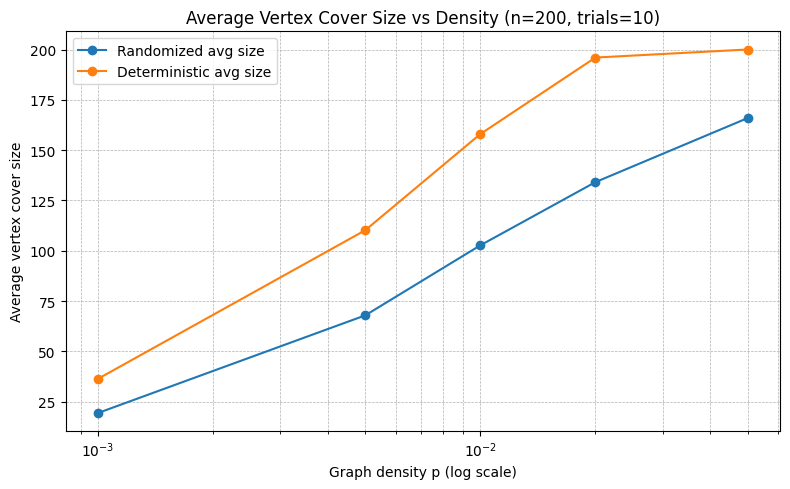

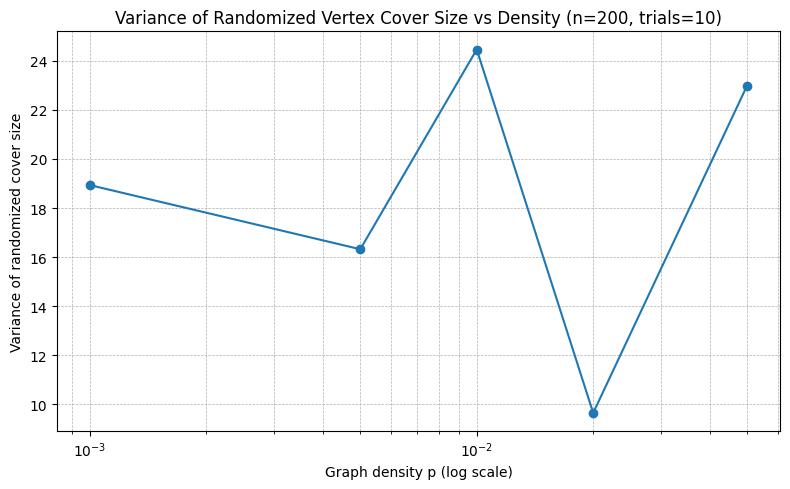

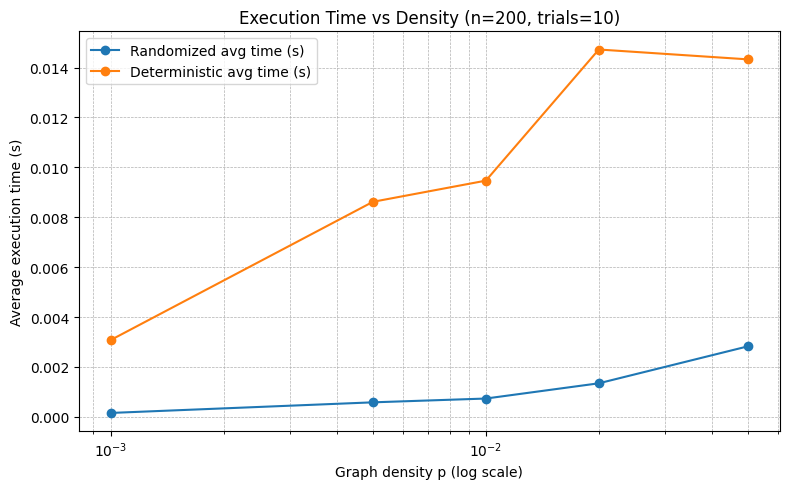


Aggregated Results:
        p  avg_rand_size  var_rand_size  avg_det_size  var_det_size  \
0  0.001           19.4      18.933333          36.4     58.488889   
1  0.005           67.9      16.322222         110.2     36.844444   
2  0.010          102.7      24.455556         158.0     53.333333   
3  0.020          134.1       9.655556         196.0      3.555556   
4  0.050          165.9      22.988889         200.0      0.000000   

   avg_rand_time  avg_det_time  
0       0.000156      0.003078  
1       0.000582      0.008619  
2       0.000734      0.009468  
3       0.001345      0.014725  
4       0.002829      0.014329  

Empirical Approximation Ratio (randomized / matching size):
        p  emp_avg_rand_over_matching
0  0.001                    1.063120
1  0.005                    1.233804
2  0.010                    1.300675
3  0.020                    1.368460
4  0.050                    1.659000


In [ ]:
# Randomized Vertex Cover

!pip install networkx pandas matplotlib --quiet

import time
import random
import multiprocessing as mp
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import logging

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")

# Randomized vertex cover
def randomized_vertex_cover(G, rng=None):
    """Randomized algorithm for vertex cover."""
    if rng is None:
        rng = random
    cover = set()
    remaining_edges = set(G.edges())
    incident = {v: set() for v in G.nodes()}
    for u, v in list(remaining_edges):
        e = (u, v)
        incident[u].add(e)
        incident[v].add(e)

    while remaining_edges:
        e = rng.choice(tuple(remaining_edges))
        u, v = e
        chosen = rng.choice((u, v))
        cover.add(chosen)
        for inc in list(incident[chosen]):
            if inc in remaining_edges:
                remaining_edges.discard(inc)
            a, b = inc
            other = b if a == chosen else a
            if inc in incident[other]:
                incident[other].discard(inc)
        incident[chosen].clear()
    return cover

# Deterministic 2-approximation

def deterministic_matching_cover(G):
    """Deterministic 2-approximation: maximal matching."""
    matching = nx.algorithms.matching.max_weight_matching(G, maxcardinality=True)
    cover = set()
    for u, v in matching:
        cover.add(u)
        cover.add(v)
    return cover

# Single trial run

def single_trial(n, p, rng_seed=None):
    rng = random.Random(rng_seed)
    G = nx.fast_gnp_random_graph(n, p, seed=rng_seed)
    t0 = time.perf_counter()
    cover_rand = randomized_vertex_cover(G, rng)
    t1 = time.perf_counter()
    cover_det = deterministic_matching_cover(G)
    t2 = time.perf_counter()
    return {
        'n': n,
        'p': p,
        'rand_size': len(cover_rand),
        'det_size': len(cover_det),
        'rand_time': t1 - t0,
        'det_time': t2 - t1
    }

def run_experiments(n=200, densities=None, trials=10, processes=1):
    if densities is None:
        densities = [0.001, 0.005, 0.01, 0.02, 0.05]
    results = []

    logging.info("Running experiments...")
    if processes is None or processes <= 1:
        for p in densities:
            for i in range(trials):
                seed = int(time.time() * 1000) ^ (i + int(p * 1e6))
                results.append(single_trial(n, p, rng_seed=seed))
    else:
        pool = mp.Pool(processes=processes)
        try:
            tasks = []
            for p in densities:
                for i in range(trials):
                    seed = (i + 1) + int(p * 1e6)
                    tasks.append((n, p, seed))
            func = lambda args: single_trial(*args)
            for res in pool.imap_unordered(func, tasks):
                results.append(res)
        finally:
            pool.close()
            pool.join()

    df = pd.DataFrame(results)
    agg = df.groupby('p').agg(
        avg_rand_size=('rand_size', 'mean'),
        var_rand_size=('rand_size', 'var'),
        avg_det_size=('det_size', 'mean'),
        var_det_size=('det_size', 'var'),
        avg_rand_time=('rand_time', 'mean'),
        avg_det_time=('det_time', 'mean')
    ).reset_index()

    df['matching_size'] = (df['det_size'] / 2).replace(0, np.nan)
    df['rand_over_matching'] = df['rand_size'] / df['matching_size']
    emp_ratio = df.groupby('p')['rand_over_matching'].mean().reset_index(name='emp_avg_rand_over_matching')

    #Plots
    plt.figure(figsize=(8, 5))
    plt.plot(agg['p'], agg['avg_rand_size'], marker='o', label='Randomized avg size')
    plt.plot(agg['p'], agg['avg_det_size'], marker='o', label='Deterministic avg size')
    plt.xscale('log')
    plt.xlabel('Graph density p (log scale)')
    plt.ylabel('Average vertex cover size')
    plt.title(f'Average Vertex Cover Size vs Density (n={n}, trials={trials})')
    plt.legend()
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(agg['p'], agg['var_rand_size'], marker='o')
    plt.xscale('log')
    plt.xlabel('Graph density p (log scale)')
    plt.ylabel('Variance of randomized cover size')
    plt.title(f'Variance of Randomized Vertex Cover Size vs Density (n={n}, trials={trials})')
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(agg['p'], agg['avg_rand_time'], marker='o', label='Randomized avg time (s)')
    plt.plot(agg['p'], agg['avg_det_time'], marker='o', label='Deterministic avg time (s)')
    plt.xscale('log')
    plt.xlabel('Graph density p (log scale)')
    plt.ylabel('Average execution time (s)')
    plt.title(f'Execution Time vs Density (n={n}, trials={trials})')
    plt.legend()
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()

    return df, agg, emp_ratio

df_all, agg, emp_ratio = run_experiments(n=200, densities=[0.001, 0.005, 0.01, 0.02, 0.05], trials=10, processes=1)

print("\nAggregated Results:\n", agg)
print("\nEmpirical Approximation Ratio (randomized / matching size):\n", emp_ratio)



3.N-Queen Variation: Blocked Cells

Problem Statement: Modify the N-Queen problem to handle blocked cells (cells where queens cannot be placed). For a given N×N board, some cells are marked as unavailable (“X”).

Tasks:

Input: N = 5 and a set of blocked coordinates.

Output all possible arrangements avoiding blocked cells.

Discuss the change in solution count compared to the standard N-Queen problem.

Example Input: N = 5 Blocked cells = [(0,2), (2,3), (3,0)] Expected Output: All valid queen placements excluding blocked cells.





Enter N (board size): 5
Enter blocked cells as row,col pairs (e.g., 0,2). Type 'done' to finish:
0,2
2,3
3,0
done

Blocked cells: [(0, 2), (2, 3), (3, 0)]

Total solutions found: 6


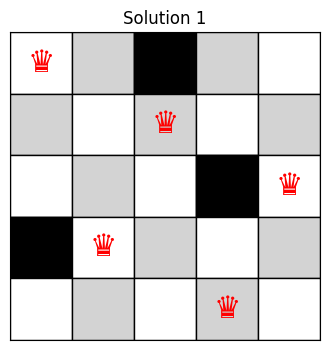

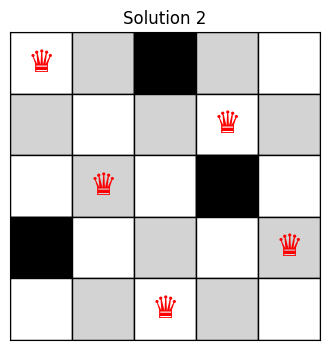

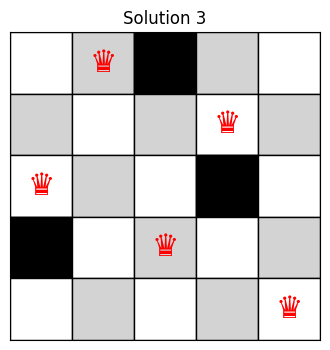

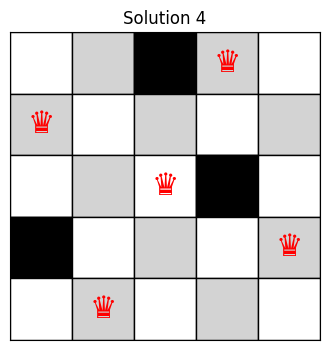

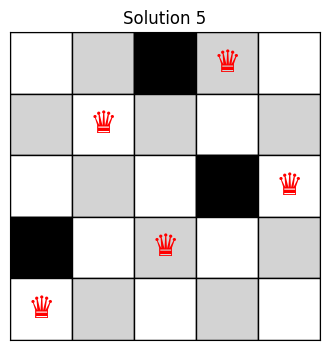

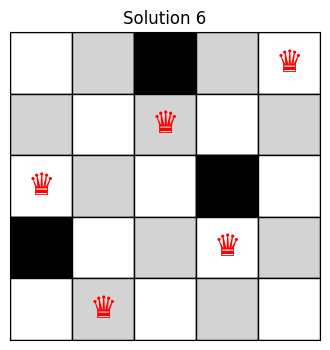

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

N = int(input("Enter N (board size): "))

print("Enter blocked cells as row,col pairs (e.g., 0,2). Type 'done' to finish:")
blocked_cells = []
while True:
    inp = input()
    if inp.lower() == 'done':
        break
    try:
        r, c = map(int, inp.split(','))
        if 0 <= r < N and 0 <= c < N:
            blocked_cells.append((r, c))
        else:
            print("Invalid coordinate — must be between 0 and", N-1)
    except:
        print("Please enter in format row,col (e.g., 2,3)")

print(f"\nBlocked cells: {blocked_cells}\n")

# Board
board = [["." for _ in range(N)] for _ in range(N)]
for (r, c) in blocked_cells:
    board[r][c] = "X"

solutions = []

# Safety
def is_safe(row, col):
    if board[row][col] == "X":
        return False
    for i in range(row):
        if board[i][col] == "Q":
            return False
    # upper-left diagonal
    i, j = row - 1, col - 1
    while i >= 0 and j >= 0:
        if board[i][j] == "Q":
            return False
        i -= 1; j -= 1
    # upper-right diagonal
    i, j = row - 1, col + 1
    while i >= 0 and j < N:
        if board[i][j] == "Q":
            return False
        i -= 1; j += 1
    return True

# Backtracking
def solve(row=0):
    if row == N:
        solutions.append(["".join(r) for r in board])
        return
    for col in range(N):
        if is_safe(row, col):
            board[row][col] = "Q"
            solve(row + 1)
            board[row][col] = "."

solve()

#Visualization
def plot_board(sol, title=""):
    fig, ax = plt.subplots(figsize=(4,4))
    for r in range(N):
        for c in range(N):
            # color pattern chess
            color = "white" if (r + c) % 2 == 0 else "lightgray"
            ax.add_patch(plt.Rectangle((c, N-1-r), 1, 1, color=color, ec="black"))
            if (r, c) in blocked_cells:
                ax.add_patch(plt.Rectangle((c, N-1-r), 1, 1, color="black"))
            elif sol[r][c] == "Q":
                ax.text(c+0.5, N-1-r+0.5, "♛", ha="center", va="center", fontsize=22, color="red")
    ax.set_xlim(0, N)
    ax.set_ylim(0, N)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title)
    plt.show()

#Solutions
print(f"Total solutions found: {len(solutions)}")
if len(solutions) == 0:
    print("No valid arrangements found.")
else:
    for i, sol in enumerate(solutions, start=1):
        plot_board(sol, f"Solution {i}")
